# **PORTFOLIO MANAGEMENT - MARKOWITZ AND OTHER VERSIONS**
## Prepared by LINH HA (University of Luxembourg)

All rights reserved.

Some code snippets for nice plotting are created by AI.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

### **Data preparation**
- *Ten securities*: TSLA, WMT, BAC, GS, LLY, MRK, GOOG, META, AAPL, XOM
- *Period*: Jan 1, 2022 to Dec 31, 2024 for modeling | Jan 1 - 31, 2025 for backtesting.
- *Frequency*: weekly

In [ ]:
#!pip install yfinance==0.2.12 # downgraded version
# !pip install --upgrade yfinance
import yfinance as yf # yahoo finance for downloading price data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from matplotlib.ticker import PercentFormatter

#### **Below code snippets are for downloading the data given the fact that you have the tickers in the format of Yahoo Finance**

In [ ]:
tickers_10 = ["TSLA", "WMT", "BAC", "GS", "LLY", "MRK", "GOOG", "META", "AAPL", "XOM"]
modeling_start = "2019-01-01"
modeling_end = "2024-12-31"
backtesting_start = "2025-01-01"
backtesting_end = "2026-01-01"

# Daily close prices
modeling_data = yf.download(tickers_10, start=modeling_start, end=modeling_end, interval='1d')['Close']
backtesting_data = yf.download(tickers_10, start=backtesting_start, end=backtesting_end, interval='1d')['Close']

# Daily returns
r_modeling = modeling_data.pct_change().dropna()
r_backtesting = backtesting_data.pct_change().dropna()


/tmp/ipykernel_1940/1641367512.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  modeling_data = yf.download(tickers_10, start=modeling_start, end=modeling_end, interval='1d')['Close']
[*********************100%***********************]  10 of 10 completed
/tmp/ipykernel_1940/1641367512.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  backtesting_data = yf.download(tickers_10, start=backtesting_start, end=backtesting_end, interval='1d')['Close']
[*********************100%***********************]  10 of 10 completed


In [ ]:
r_modeling.head(3)

Ticker,AAPL,BAC,GOOG,GS,LLY,META,MRK,TSLA,WMT,XOM
Date,,,,,,,,,,
2019-01-03,-0.099607,-0.016025,-0.028484,-0.014649,-0.031076,-0.029039,-0.020505,-0.031472,-0.005143,-0.015353
2019-01-04,0.042689,0.041531,0.053786,0.032682,0.030096,0.047138,0.030119,0.057697,0.006246,0.036869
2019-01-07,-0.002226,-0.000782,-0.002167,0.005541,0.005407,0.000725,-0.011014,0.054361,0.011772,0.005201


In [ ]:
r_backtesting.head(3)

Ticker,AAPL,BAC,GOOG,GS,LLY,META,MRK,TSLA,WMT,XOM
Date,,,,,,,,,,
2025-01-03,-0.002009,0.011741,0.013115,0.008974,0.005025,0.008995,-0.000303,0.082156,0.008667,0.005125
2025-01-06,0.006739,0.013167,0.025009,0.005619,-0.021586,0.042290,0.005850,0.001486,0.007160,-0.001112
2025-01-07,-0.011388,0.014978,-0.006314,-0.005605,0.010705,-0.019533,0.013037,-0.040603,-0.006781,0.009374


Plotting the cummulative returns of 10 stocks:

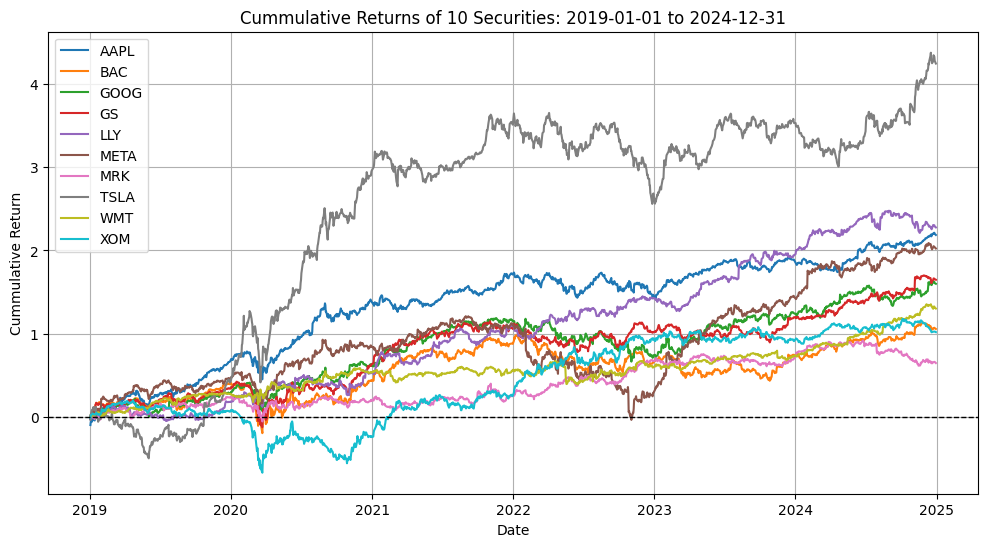

In [ ]:
def plot_weekly_returns(returns, title):
    plt.figure(figsize=(12, 6))
    for column in returns.columns:
        plt.plot(returns.index, returns[column].cumsum(), label=column)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Cummulative Return")
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.legend(loc="upper left")
    plt.grid()
    plt.show()

plot_weekly_returns(r_modeling, f"Cummulative Returns of 10 Securities: {modeling_start} to {modeling_end}")

## **MEAN-VARIANCE PORTFOLIOS WITH 10 STOCKS**

### **I. Optimal mean-variance portfolio**
**Requirements**
- Weights must sum to 1
- No short-selling

Optimization problem:

$$\max_w w^{\top} r - \frac{1}{2} w^{\top} \Sigma w$$

subject to

$$w^{\top} [1]_N = 1, \quad w \geq [0]_N, $$

in which:
- $w \in R^N$: weight vector
- $r \in R^N$: vector of expected returns from $N$ assets in the portfolio.
- $\Sigma \in R^{N \times N}$: covariance matrix of assets' returns.
- $[1]_N : N \times 1$ all-one vector (vector with all elements as $1$)
- $[0]_N : N \times 1$ all-zero vector (vector with all $0$ elements)

In [ ]:
# Compute the expected return vector and covariance matrix

mu_model = r_modeling.mean()
mu_backtest= r_backtesting.mean()

cov_model = r_modeling.cov()
cov_backtest = r_backtesting.cov()

#print("Expected weekly Returns (Modeling):\n", mu_model)
#print("\nCovariance Matrix (Modeling):\n", cov_model)

#print("\nExpected weekly Returns (Backtesting):\n", mu_backtest)
#print("\nCovariance Matrix (Backtesting):\n", cov_backtest)

In [ ]:
Sigma = np.array(cov_model)
r_exp = np.array(mu_model)
N = len(r_exp)

# Equality contraints: Aw = b
A = np.ones([N,1])
b = np.array([1])

# Inequality constraints: -w <= 0
G_1 = np.diag([-1] * N)
h_1 = np.zeros(N)
asset_names = list(mu_model.index)

Function `MVO_portfolio` solves a simple  mean-variance portfolio optimization problem.

The solver `cvxpy` solve the optimization problem:

$$\max_w f(w)$$

such that:

$$Aw = b$$

$$G x \leq h$$

for $w \in \mathbb{R}^N$, $A \in \mathbb{R}^{k\times N}$ for $k$ equality constraints, $b\in \mathbb{R}^k$ and $G\in \mathbb{R}^{m \times N}$, $h \in \mathbb{R}^m$ for $m$ inequality constraints.

In [ ]:
import cvxpy as cvx

def MVO_portfolio(Sigma, r_exp, A, b,G, h, lambda_=0.5,):
    """
    Solve a mean-variance portfolio optimization problem.

    Objective
    ---------
    Maximize:

        expected return - lambda_/2 * portfolio variance

    Constraints
    -----------
    G @ w <= h
    A.T @ w == b

    Parameters
    ----------
    Sigma : array-like
        Covariance matrix.

    r_exp : array-like
        Expected-return vector.

    A : array-like
        Equality-constraint vector or matrix.

    b : float or array-like
        Equality-constraint value.

    G : array-like
        Inequality-constraint matrix.

    h : array-like
        Inequality-constraint vector.

    lambda_ : float
        Risk-aversion parameter. It must be nonnegative.

    Returns
    -------
    w_opt : numpy.ndarray
        Optimal portfolio weights.
    """

    if lambda_ < 0:
        raise ValueError(
            "The risk-aversion parameter must be nonnegative."
        )

    Sigma = np.asarray(Sigma, dtype=float)
    r_exp = np.asarray(r_exp, dtype=float).flatten()
    A = np.asarray(A, dtype=float)
    G = np.asarray(G, dtype=float)
    h = np.asarray(h, dtype=float)

    N = len(r_exp)
    w = cvx.Variable(N)

    portfolio_return = r_exp @ w

    portfolio_variance = cvx.quad_form(
        w,
        cvx.psd_wrap(Sigma),
    )

    objective = cvx.Maximize(
        portfolio_return
        - lambda_ / 2 * portfolio_variance
    )

    constraints = [
        G @ w <= h,
        A.T @ w == b,
    ]

    problem = cvx.Problem(
        objective,
        constraints,
    )

    problem.solve()

    if problem.status not in {
        cvx.OPTIMAL,
        cvx.OPTIMAL_INACCURATE,
    }:
        raise ValueError(
            f"Optimization failed: {problem.status}"
        )

    w_opt = np.asarray(w.value).flatten()

    # Remove small numerical errors.
    w_opt[np.abs(w_opt) < 1e-8] = 0

    return w_opt

- Optimal weights:

In [ ]:
w_opt_1 = MVO_portfolio(Sigma, r_exp, A, b,G_1, h_1, lambda_=1)
w_series_1 = pd.Series(w_opt_1, index=mu_model.index).apply(lambda x: f"{x:.4f}")
print('Optimal weights of our 10-stock portfolio in Step 1: ', w_series_1)


Optimal weights of our 10-stock portfolio in Step 1:  Ticker
AAPL    0.0000
BAC     0.0000
GOOG    0.0000
GS      0.0000
LLY     0.1467
META    0.0000
MRK     0.0000
TSLA    0.8533
WMT     0.0000
XOM     0.0000
dtype: object


- Mean-Variance portfolio (no short selling) return:

In [ ]:
opt_ptf_ret_1 = np.dot(w_opt_1, r_exp)
print("Expected return optimal porfolio (no short selling): ", f"{opt_ptf_ret_1:.2%}")

Expected return optimal porfolio (no short selling):  0.26%


- Mean-Variance Portfolio (no short selling) Volatility:

In [ ]:
opt_ptf_std_1 = np.sqrt(np.dot(w_opt_1, Sigma.dot(w_opt_1.T)))
print("Expected std. deviation optimal porfolio (no short selling): ", f"{opt_ptf_std_1:.2%}")

Expected std. deviation optimal porfolio (no short selling):  3.50%


#### **Efficient Frontier**

In [ ]:
# Sampling risk-aversion parameters
#--- Small lambda_: MVP closer to Global Maximum Return Portfolio
#--- Large lambda_: MVP closer to Global Mininum Variance Portfolio
lambda_values = np.logspace(
    -3,
    5,
    300,
)

frontier_results = []
frontier_weights = []

for lambda_ in lambda_values:

    weights = MVO_portfolio(
        Sigma=Sigma,
        r_exp=r_exp,
        A=A,
        b=b,
        G=G_1,
        h=h_1,
        lambda_=lambda_,
    )

    portfolio_return = (
        r_exp.T @ weights
    )

    portfolio_variance = (
        weights.T
        @ Sigma
        @ weights
    )

    portfolio_volatility = np.sqrt(
        max(portfolio_variance, 0)
    )

    frontier_results.append(
        {
            "Lambda": lambda_,
            "Return": portfolio_return,
            "Volatility": portfolio_volatility,
        }
    )

    frontier_weights.append(weights)

frontier = pd.DataFrame(frontier_results)

frontier_weights = pd.DataFrame(
    frontier_weights,
    columns=asset_names,
)

In [ ]:
# Global maximum-return portfolio: lambda_ = 0
maximum_return_weights = MVO_portfolio(
    Sigma=Sigma,
    r_exp=r_exp,
    A=A,
    b=b,
    G=G_1,
    h=h_1,
    lambda_=0,
)

maximum_return = (
    r_exp.T @ maximum_return_weights
)

maximum_return_variance = (
    maximum_return_weights.T
    @ Sigma
    @ maximum_return_weights
)

maximum_return_volatility = np.sqrt(
    max(maximum_return_variance, 0)
)

In [ ]:
# Global minimum-risk portfolio

w_minimum_risk = cvx.Variable(N)

minimum_risk_objective = cvx.Minimize(
    cvx.quad_form(
        w_minimum_risk,
        cvx.psd_wrap(Sigma),
    )
)

minimum_risk_constraints = [
    G_1 @ w_minimum_risk <= h_1,
    A.T @ w_minimum_risk == b,
]

minimum_risk_problem = cvx.Problem(
    minimum_risk_objective,
    minimum_risk_constraints,
)

minimum_risk_problem.solve()

if minimum_risk_problem.status not in {
    cvx.OPTIMAL,
    cvx.OPTIMAL_INACCURATE,
}:
    raise ValueError(
        "Minimum-risk optimization failed: "
        f"{minimum_risk_problem.status}"
    )

minimum_risk_weights = np.asarray(
    w_minimum_risk.value
).flatten()

minimum_risk_weights[
    np.abs(minimum_risk_weights) < 1e-8
] = 0

minimum_risk_return = (
    r_exp.T @ minimum_risk_weights
)

minimum_risk_variance = (
    minimum_risk_weights.T
    @ Sigma
    @ minimum_risk_weights
)

minimum_risk_volatility = np.sqrt(
    max(minimum_risk_variance, 0)
)

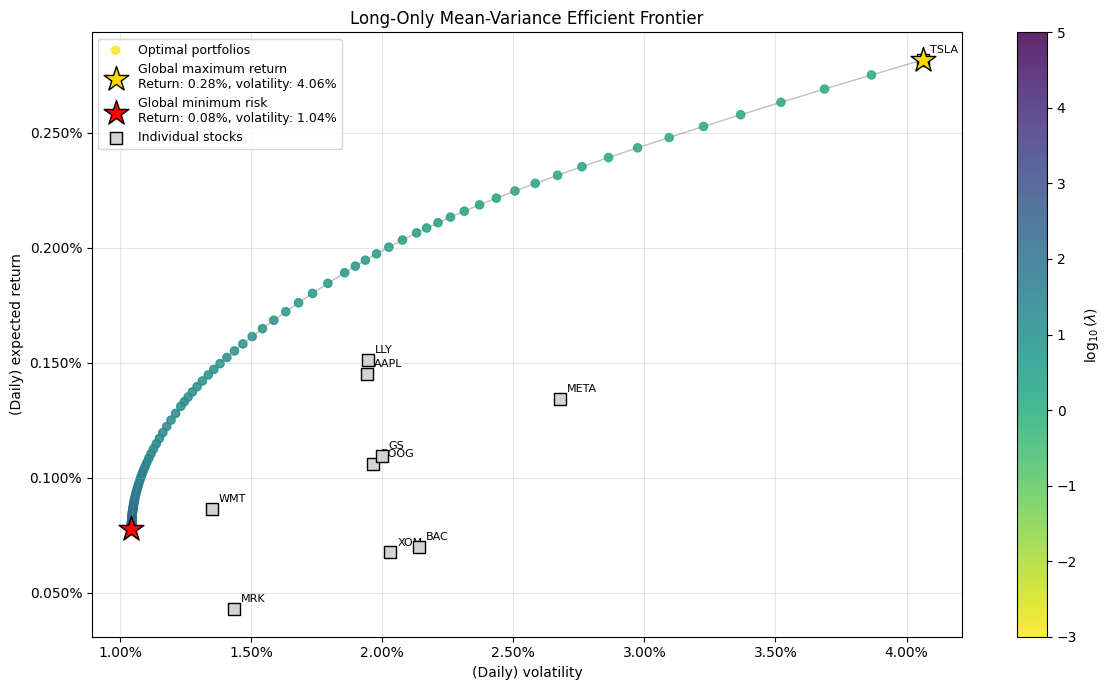

In [ ]:
# Plot the efficient frontier

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    frontier["Volatility"],
    frontier["Return"],
    c=np.log10(frontier["Lambda"]),
    cmap="viridis_r",
    s=35,
    alpha=0.85,
    label="Optimal portfolios",
)

ax.plot(
    frontier["Volatility"],
    frontier["Return"],
    color="gray",
    linewidth=1,
    alpha=0.5,
)

# Global maximum-return portfolio
ax.scatter(
    maximum_return_volatility,
    maximum_return,
    marker="*",
    s=350,
    color="gold",
    edgecolor="black",
    label=(
        "Global maximum return\n"
        f"Return: {maximum_return:.2%}, "
        f"volatility: {maximum_return_volatility:.2%}"
    ),
    zorder=5,
)

# Global minimum-risk portfolio
ax.scatter(
    minimum_risk_volatility,
    minimum_risk_return,
    marker="*",
    s=350,
    color="red",
    edgecolor="black",
    label=(
        "Global minimum risk\n"
        f"Return: {minimum_risk_return:.2%}, "
        f"volatility: {minimum_risk_volatility:.2%}"
    ),
    zorder=5,
)

# Individual stocks
individual_volatilities = np.sqrt(
    np.diag(Sigma)
)

ax.scatter(
    individual_volatilities,
    r_exp,
    marker="s",
    s=65,
    color="lightgray",
    edgecolor="black",
    label="Individual stocks",
    zorder=4,
)

for i, ticker in enumerate(asset_names):
    ax.annotate(
        ticker,
        (
            individual_volatilities[i],
            r_exp[i],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

colorbar = fig.colorbar(
    scatter,
    ax=ax,
)

colorbar.set_label(
    r"$\log_{10}(\lambda)$"
)

ax.set_title(
    "Long-Only Mean-Variance Efficient Frontier"
)

ax.set_xlabel("(Daily) volatility")
ax.set_ylabel("(Daily) expected return")

ax.xaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

---
## **II. Optimal mean-variance portfolio with box constraints**
**Requirements**
- As above
- No asset represents more than 15% of the portfolio ($w_i \leq 0.15$ for all $i = 1, ..., 10$).

Optimization problem:

$$\max_w w^{\top} r - \frac{1}{2} w^{\top} \Sigma w$$

subject to

$$w^{\top} [1]_N = 1, \quad w \geq [0]_N,  \quad w \leq 0.15 \times [1]_N$$

In [ ]:
# New inequality constraints: including box contraints
G_2 = np.vstack((np.diag([-1] * N), np.diag([1] * N)))
h_2 =  np.hstack((np.zeros(N), 0.15*np.ones(N)))

- Optimal weights (box constrained):

In [ ]:
w_opt_2 = MVO_portfolio(Sigma, r_exp, A, b, G_2, h_2, lambda_=1)
w_series_2 = pd.Series(w_opt_2, index=mu_model.index).apply(lambda x: f"{x:.4f}")
print('Optimal weights of our 10-stock portfolio (no short selling + box constrained): ', w_series_2)

Optimal weights of our 10-stock portfolio (no short selling + box constrained):  Ticker
AAPL    0.1500
BAC     0.0000
GOOG    0.1500
GS      0.1500
LLY     0.1500
META    0.1500
MRK     0.0000
TSLA    0.1500
WMT     0.1000
XOM     0.0000
dtype: object


- Mean-Variance portfolio (no short selling + box constrained) return:

In [ ]:
opt_ptf_ret_2 = np.dot(w_opt_2, r_exp)
print("Expected return optimal porfolio (no short selling + box constrained): ", f"{opt_ptf_ret_2:.2%}")

Expected return optimal porfolio (no short selling + box constrained):  0.15%


- Mean-Variance Portfolio (no short selling + box constrained) Volatility:

In [ ]:
opt_ptf_std_2 = np.sqrt(np.dot(w_opt_2, Sigma.dot(w_opt_2.T)))
print("Expected std. deviation optimal porfolio (no short selling+ box constrained): ", f"{opt_ptf_std_2:.2%}")

Expected std. deviation optimal porfolio (no short selling+ box constrained):  1.58%


### **III. Compare the efficient frontiers in Sections I & II**

In [ ]:
# Generate a frontier by varying risk aversion

def generate_frontier(Sigma, r_exp, A, b, G, h, lambda_values,):
    """
    Generate optimal portfolios by varying the risk-aversion
    parameter.
    """

    results = []
    weights_list = []

    for lambda_ in lambda_values:

        weights = MVO_portfolio(
            Sigma=Sigma,
            r_exp=r_exp,
            A=A,
            b=b,
            G=G,
            h=h,
            lambda_=lambda_,
        )

        portfolio_return = (
            r_exp.T @ weights
        )

        portfolio_variance = (
            weights.T
            @ Sigma
            @ weights
        )

        portfolio_volatility = np.sqrt(
            max(portfolio_variance, 0)
        )

        results.append(
            {
                "Lambda": lambda_,
                "Annual return": portfolio_return,
                "Annual volatility": portfolio_volatility,
            }
        )

        weights_list.append(weights)

    results = pd.DataFrame(results)

    weights_list = np.asarray(weights_list)

    # Arrange the points from low to high volatility.
    results = results.sort_values(
        "Annual volatility"
    ).reset_index(drop=True)

    return results, weights_list

In [ ]:
# Compute both efficient frontiers

lambda_values = np.logspace(
    -3,
    5,
    300,
)

frontier_1, weights_1 = generate_frontier(
    Sigma=Sigma,
    r_exp=r_exp,
    A=A,
    b=b,
    G=G_1,
    h=h_1,
    lambda_values=lambda_values,
)

frontier_2, weights_2 = generate_frontier(
    Sigma=Sigma,
    r_exp=r_exp,
    A=A,
    b=b,
    G=G_2,
    h=h_2,
    lambda_values=lambda_values,
)

In [ ]:
# Compute frontier endpoints

def frontier_endpoints(Sigma, r_exp, A, b, G, h,):
    """
    Calculate the global minimum-risk and maximum-return
    portfolios for a given constraint set.
    """

    N = len(r_exp)

    #---Global maximum-return portfolio

    maximum_return_weights = MVO_portfolio(
        Sigma=Sigma,
        r_exp=r_exp,
        A=A,
        b=b,
        G=G,
        h=h,
        lambda_=0,
    )

    maximum_return = (
        r_exp.T @ maximum_return_weights
    )

    maximum_return_volatility = np.sqrt(
        maximum_return_weights.T
        @ Sigma
        @ maximum_return_weights
    )

    #--- Global minimum-risk portfolio

    w = cvx.Variable(N)

    problem = cvx.Problem(
        cvx.Minimize(
            cvx.quad_form(
                w,
                cvx.psd_wrap(Sigma),
            )
        ),
        [
            G @ w <= h,
            A.T @ w == b,
        ],
    )

    problem.solve()

    if problem.status not in {
        cvx.OPTIMAL,
        cvx.OPTIMAL_INACCURATE,
    }:
        raise ValueError(
            f"Optimization failed: {problem.status}"
        )

    minimum_risk_weights = np.asarray(
        w.value
    ).flatten()

    minimum_risk_weights[
        np.abs(minimum_risk_weights) < 1e-8
    ] = 0

    minimum_risk_return = (
        r_exp.T @ minimum_risk_weights
    )

    minimum_risk_volatility = np.sqrt(
        minimum_risk_weights.T
        @ Sigma
        @ minimum_risk_weights
    )

    return {
        "minimum_weights": minimum_risk_weights,
        "minimum_return": minimum_risk_return,
        "minimum_volatility": minimum_risk_volatility,
        "maximum_weights": maximum_return_weights,
        "maximum_return": maximum_return,
        "maximum_volatility": maximum_return_volatility,
    }


endpoints_1 = frontier_endpoints(Sigma, r_exp, A, b, G_1, h_1,)

endpoints_2 = frontier_endpoints(Sigma, r_exp, A, b, G_2, h_2,)

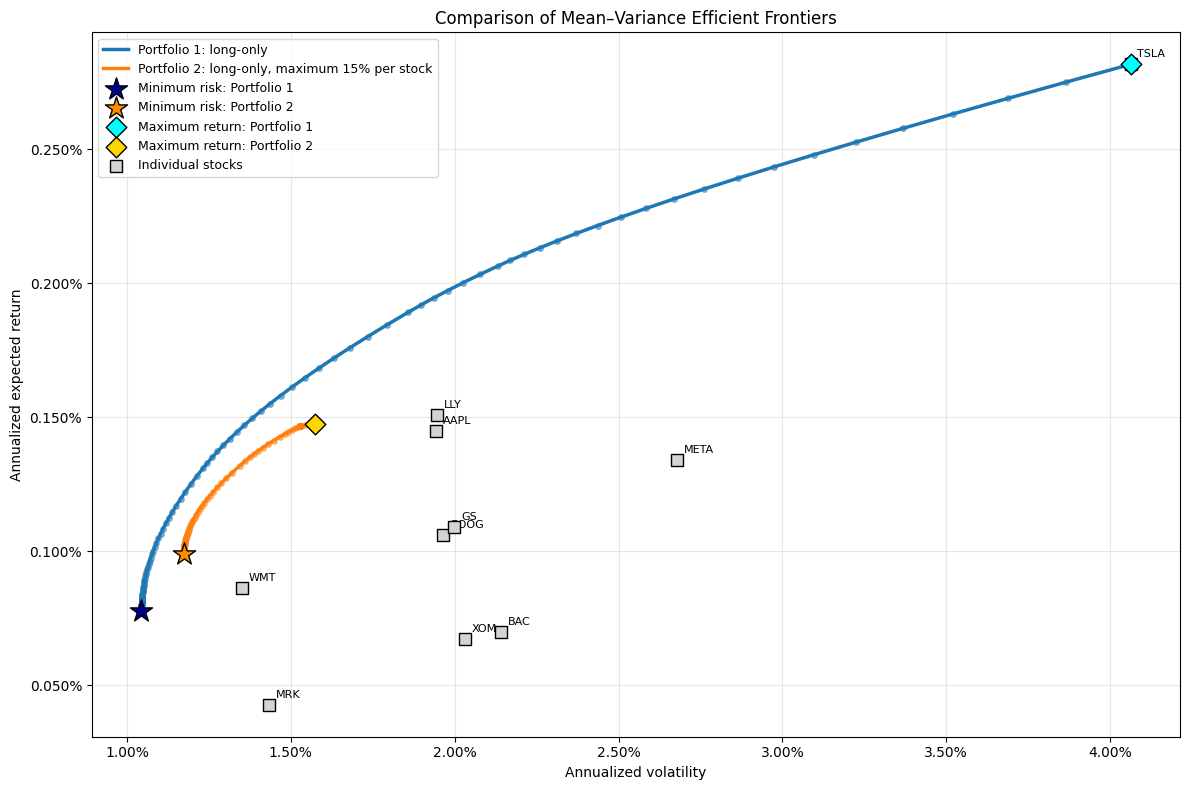

In [ ]:
# Plot both efficient frontiers

fig, ax = plt.subplots(figsize=(12, 8))

# Portfolio 1
ax.plot(
    frontier_1["Annual volatility"],
    frontier_1["Annual return"],
    color="tab:blue",
    linewidth=2.5,
    label="Portfolio 1: long-only",
)

ax.scatter(
    frontier_1["Annual volatility"],
    frontier_1["Annual return"],
    color="tab:blue",
    s=16,
    alpha=0.5,
)

# Portfolio 2
ax.plot(
    frontier_2["Annual volatility"],
    frontier_2["Annual return"],
    color="tab:orange",
    linewidth=2.5,
    label="Portfolio 2: long-only, maximum 15% per stock",
)

ax.scatter(
    frontier_2["Annual volatility"],
    frontier_2["Annual return"],
    color="tab:orange",
    s=16,
    alpha=0.5,
)


# Minimum-risk portfolios

ax.scatter(
    endpoints_1["minimum_volatility"],
    endpoints_1["minimum_return"],
    marker="*",
    s=280,
    color="darkblue",
    edgecolor="black",
    label="Minimum risk: Portfolio 1",
    zorder=5,
)

ax.scatter(
    endpoints_2["minimum_volatility"],
    endpoints_2["minimum_return"],
    marker="*",
    s=280,
    color="darkorange",
    edgecolor="black",
    label="Minimum risk: Portfolio 2",
    zorder=5,
)


# Maximum-return portfolios

ax.scatter(
    endpoints_1["maximum_volatility"],
    endpoints_1["maximum_return"],
    marker="D",
    s=110,
    color="cyan",
    edgecolor="black",
    label="Maximum return: Portfolio 1",
    zorder=5,
)

ax.scatter(
    endpoints_2["maximum_volatility"],
    endpoints_2["maximum_return"],
    marker="D",
    s=110,
    color="gold",
    edgecolor="black",
    label="Maximum return: Portfolio 2",
    zorder=5,
)

# Individual stocks
individual_volatilities = np.sqrt(
    np.diag(Sigma)
)

ax.scatter(
    individual_volatilities,
    r_exp,
    marker="s",
    s=65,
    color="lightgray",
    edgecolor="black",
    label="Individual stocks",
    zorder=4,
)

for i, ticker in enumerate(asset_names):
    ax.annotate(
        ticker,
        (
            individual_volatilities[i],
            r_exp[i],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

# Formatting

ax.set_title(
    "Comparison of Mean–Variance Efficient Frontiers"
)

ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized expected return")

ax.xaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

### **4. Backtesting the portfolio performance during period Jan 1 2025 - Jan 31, 2026**

Now we have 2 weights for 2 optimimal portfolios: `w_opt_1` and `w_opt_2`.

Now I have to backtest for the data return in period: Jan 1 2025 - Jan 31, 2026.

We will compare 2 optimal portfolios' returns in this period.

- The benchmark portfolio to compare is the equal weight portfolio ($w_1 = ... = w_N = \frac{1}{N}$).

First, let's see how individual stock behave during this backtesting period:

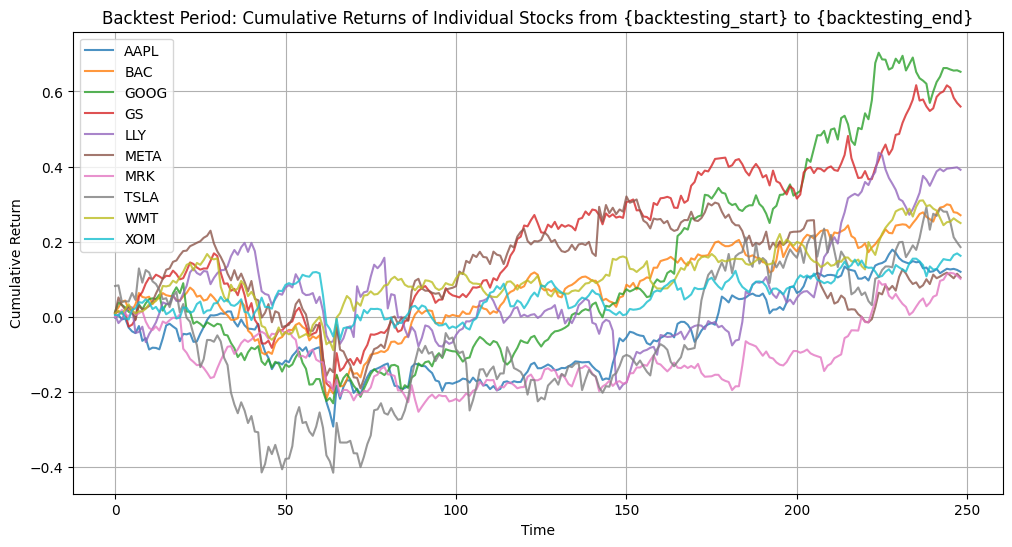

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

r_backtest_np = r_backtesting.to_numpy() if hasattr(r_backtesting, "to_numpy") else np.array(r_backtesting)

cumulative_stocks = np.cumprod(1 + r_backtest_np, axis=0) - 1

stock_names = r_backtesting.columns if hasattr(r_backtesting, "columns") else [f"Stock {i+1}" for i in range(N)]

plt.figure(figsize=(12, 6))
for i in range(N):
    plt.plot(cumulative_stocks[:, i], alpha=0.8, label=stock_names[i])

plt.title("Backtest Period: Cumulative Returns of Individual Stocks from {backtesting_start} to {backtesting_end}")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()


Now is the performance of our portfolios (vs benchmark):

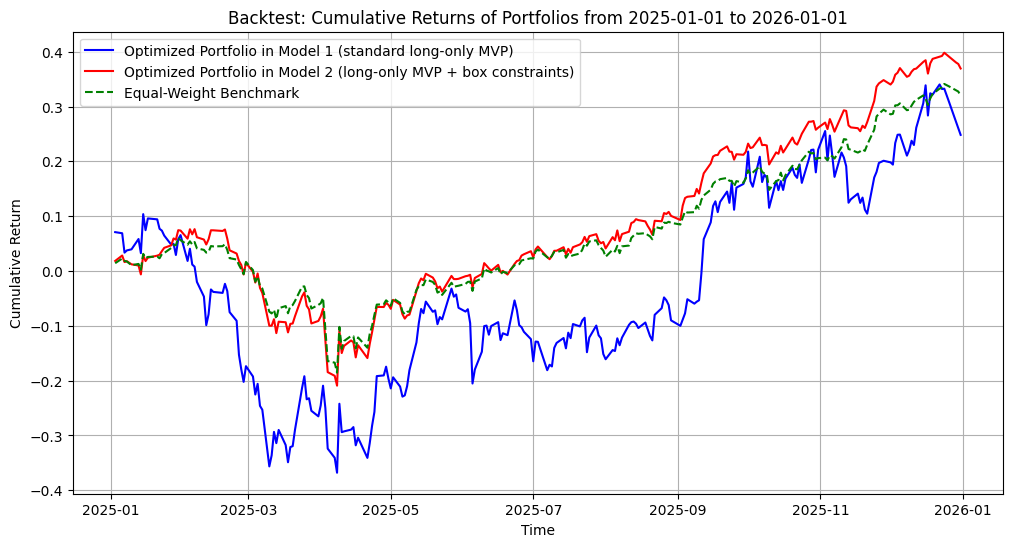

In [ ]:
# Optimal portfolio returns
r_port_1 = r_backtesting @ w_opt_1
r_port_2 = r_backtesting @ w_opt_2

# Equal-weight benchmark portfolio
N = r_backtesting.shape[1]
w_equal = np.ones(N) / N
r_benchmark = r_backtesting @ w_equal

# Cumulative returns
cumulative_ret_1 = np.cumprod(1 + r_port_1) - 1
cumulative_ret_2 = np.cumprod(1 + r_port_2) - 1
cumulative_benchmark = np.cumprod(1 + r_benchmark) - 1

# Plot
plt.figure(figsize=(12, 6))
plt.plot(cumulative_ret_1, label="Optimized Portfolio in Model 1 (standard long-only MVP)", color='b')
plt.plot(cumulative_ret_2, label="Optimized Portfolio in Model 2 (long-only MVP + box constraints)", color='r')
plt.plot(cumulative_benchmark, label="Equal-Weight Benchmark", linestyle='dashed', color='g')

plt.title(f"Backtest: Cumulative Returns of Portfolios from {backtesting_start} to {backtesting_end}")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()
